In [84]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

In [85]:
#TASK ONE
taxi = pd.read_csv(TAXI_URL)
taxi.shape




(41202, 13)

In [86]:
taxi.head()

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


In [87]:
taxi.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


In [88]:
taxi.describe()


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000


In [89]:
taxi.isna().sum()

#there are no missing values in any of the columns


,0
VendorID,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,0
mta_tax,0


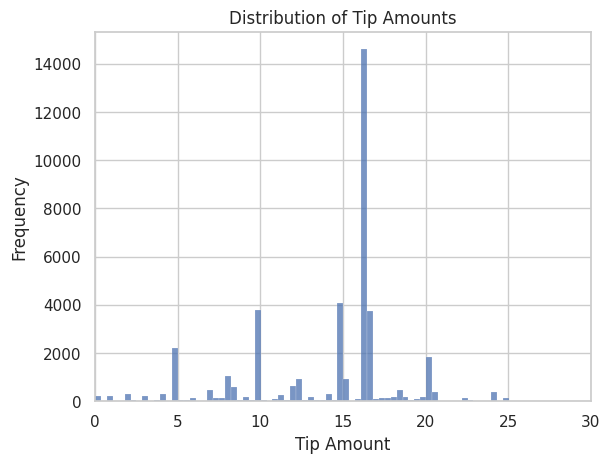

In [90]:

tip_amount = sns.histplot(data=taxi, x='tip_amount')

plt.xlabel('Tip Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Tip Amounts')
plt.xlim(0,30)
plt.show()


#there are 41202 rows and 13 columns
#so far, there are no missing values. But there is a trip distance of 0 which seems to be quite strange. There is still a possibility of negative or impossible values in other columns within the dataset.
#tip amount distribution is left-skewed
#in the case where such values are found, i will have to drop the zero values, and handle the negative or impossible values in order to yield accurate results.

In [91]:


# 1.2 Cleaning

print("Rows BEFORE cleaning:", taxi.shape)

taxi = taxi[
    (taxi["trip_distance"] > 0) &
    (taxi["fare_amount"] > 0) &
    (taxi["tip_amount"] >= 0)
]

print("Rows AFTER cleaning:", taxi.shape)
print("Zero distances:", (taxi["trip_distance"] == 0).sum())
print("Min distance:", taxi["trip_distance"].min())

#I removed zero and negative trip distance, non-positive fare fees and negative tip amounts.






Rows BEFORE cleaning: (41202, 13)
Rows AFTER cleaning: (41126, 13)
Zero distances: 0
Min distance: 0.01


In [92]:
#counting the negative values in each column
numeric_cols = taxi.select_dtypes(include='number').columns

for col in numeric_cols:
    print(col, (taxi[col] < 0).sum())
#no negative values are recorded



VendorID 0
passenger_count 0
trip_distance 0
RatecodeID 0
store_and_fwd_flag 0
PULocationID 0
DOLocationID 0
payment_type 0
fare_amount 0
mta_tax 0
tolls_amount 0
improvement_surcharge 0
tip_amount 0


In [93]:
#Feature engineering — create at least ONE new, justified feature
taxi['fare_per_mile'] = taxi.fare_amount / taxi.trip_distance
taxi['total_surcharges'] = taxi.mta_tax + taxi.tolls_amount + taxi.improvement_surcharge

#categorical variables
categorical_cols = ['VendorID', 'RatecodeID','store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type']
numeric_cols = ['passenger_count','trip_distance', 'fare_amount','mta_tax','tolls_amount', 'improvement_surcharge']


#I engineered fare_per_mile and total_surcharges, where fare_per_mile tracks how expensive it was to travel per mile.
#total_surcharges tracks all extra charges and puts them into one feature.


In [94]:
taxi_encoded = pd.get_dummies(taxi, columns=categorical_cols, drop_first = True)
taxi_encoded.head()

,passenger_count,trip_distance,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount,fare_per_mile,total_surcharges,RatecodeID_2,RatecodeID_4,RatecodeID_5,store_and_fwd_flag_1,PULocationID_43,PULocationID_48,PULocationID_50,PULocationID_56,PULocationID_62,PULocationID_68,PULocationID_70,PULocationID_75,PULocationID_76,PULocationID_79,PULocationID_82,PULocationID_83,PULocationID_87,PULocationID_90,PULocationID_113,PULocationID_129,PULocationID_130,PULocationID_132,PULocationID_134,PULocationID_138,PULocationID_141,PULocationID_142,PULocationID_145,PULocationID_148,PULocationID_161,PULocationID_162,PULocationID_163,PULocationID_166,PULocationID_170,PULocationID_181,PULocationID_186,PULocationID_194,PULocationID_198,PULocationID_209,PULocationID_213,PULocationID_215,PULocationID_216,PULocationID_219,PULocationID_223,PULocationID_230,PULocationID_231,PULocationID_236,PULocationID_243,PULocationID_255,PULocationID_260,PULocationID_261,PULocationID_262,PULocationID_264,DOLocationID_4,DOLocationID_7,DOLocationID_9,DOLocationID_10,DOLocationID_11,DOLocationID_12,DOLocationID_13,DOLocationID_14,DOLocationID_15,DOLocationID_16,DOLocationID_17,DOLocationID_19,DOLocationID_20,DOLocationID_21,DOLocationID_22,DOLocationID_24,DOLocationID_25,DOLocationID_26,DOLocationID_28,DOLocationID_29,DOLocationID_33,DOLocationID_35,DOLocationID_36,DOLocationID_37,DOLocationID_38,DOLocationID_39,DOLocationID_40,DOLocationID_41,DOLocationID_42,DOLocationID_43,DOLocationID_44,DOLocationID_45,DOLocationID_48,DOLocationID_49,DOLocationID_50,DOLocationID_51,DOLocationID_52,DOLocationID_53,DOLocationID_54,DOLocationID_55,DOLocationID_56,DOLocationID_57,DOLocationID_58,DOLocationID_60,DOLocationID_61,DOLocationID_62,DOLocationID_63,DOLocationID_64,DOLocationID_65,DOLocationID_66,DOLocationID_67,DOLocationID_68,DOLocationID_70,DOLocationID_71,DOLocationID_72,DOLocationID_74,DOLocationID_75,DOLocationID_76,DOLocationID_77,DOLocationID_79,DOLocationID_80,DOLocationID_81,DOLocationID_82,DOLocationID_83,DOLocationID_85,DOLocationID_86,DOLocationID_87,DOLocationID_88,DOLocationID_89,DOLocationID_90,DOLocationID_91,DOLocationID_92,DOLocationID_93,DOLocationID_95,DOLocationID_97,DOLocationID_98,DOLocationID_100,DOLocationID_101,DOLocationID_102,DOLocationID_106,DOLocationID_107,DOLocationID_108,DOLocationID_111,DOLocationID_112,DOLocationID_113,DOLocationID_114,DOLocationID_116,DOLocationID_117,DOLocationID_118,DOLocationID_119,DOLocationID_121,DOLocationID_122,DOLocationID_123,DOLocationID_124,DOLocationID_125,DOLocationID_127,DOLocationID_128,DOLocationID_129,DOLocationID_130,DOLocationID_131,DOLocationID_132,DOLocationID_133,DOLocationID_134,DOLocationID_135,DOLocationID_137,DOLocationID_138,DOLocationID_139,DOLocationID_140,DOLocationID_141,DOLocationID_142,DOLocationID_143,DOLocationID_144,DOLocationID_145,DOLocationID_146,DOLocationID_148,DOLocationID_149,DOLocationID_150,DOLocationID_151,DOLocationID_152,DOLocationID_154,DOLocationID_155,DOLocationID_157,DOLocationID_158,DOLocationID_160,DOLocationID_161,DOLocationID_162,DOLocationID_163,DOLocationID_164,DOLocationID_165,DOLocationID_166,DOLocationID_167,DOLocationID_168,DOLocationID_169,DOLocationID_170,DOLocationID_171,DOLocationID_174,DOLocationID_175,DOLocationID_177,DOLocationID_178,DOLocationID_179,DOLocationID_180,DOLocationID_181,DOLocationID_185,DOLocationID_186,DOLocationID_188,DOLocationID_189,DOLocationID_190,DOLocationID_191,DOLocationID_192,DOLocationID_193,DOLocationID_195,DOLocationID_196,DOLocationID_197,DOLocationID_198,DOLocationID_200,DOLocationID_201,DOLocationID_202,DOLocationID_203,DOLocationID_205,DOLocationID_206,DOLocationID_208,DOLocationID_209,DOLocationID_210,DOLocationID_211,DOLocationID_213,DOLocationID_215,DOLocationID_216,DOLocationID_218,DOLocationID_219,DOLocationID_220,DOLocationID_222,DOLocationID_223,DOLocationID_224,DOLocationID_225,DOLocationID_226,DOLocationID_227,DOLocationID_228,DOLocationID_229,DOLocationID_230,DOLocationID_231,DOLocationID_232,DOLocationID

In [118]:
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#To scale, I used StandardScaler because numeric variables have different ranges and values, allowing the model to treat each feature more consistently.



In [119]:
#1.3
from sklearn.model_selection import train_test_split
X = taxi_encoded.drop(columns=['tip_amount'])
y = taxi_encoded['tip_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


#I used a ratio of 60:20:20 for training, validation and test respectively.
#Validation set was used to test various models while keeping a separate set for final validation.
#The scaler is fit on the training data to prevent data leakage because that could lead to evaluation being overly optimistic.

(24675, 270)
(8225, 270)
(8226, 270)


In [121]:
#1.4
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

train_pred = linear_model.predict(X_train)
val_pred = linear_model.predict(X_val)
test_pred = linear_model.predict(X_test)

train_rmse = mean_squared_error(y_train, train_pred) ** 0.5
val_rmse = mean_squared_error(y_val, val_pred) ** 0.5
test_rmse = mean_squared_error(y_test, test_pred) ** 0.5

train_r2 = r2_score(y_train, train_pred)
val_r2 = r2_score(y_val, val_pred)
test_r2 = r2_score(y_test, test_pred)

print("Linear Regression Results")

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Validation RMSE: {val_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

print(f"Train R2: {train_r2:.2f}")
print(f"Validation R2: {val_r2:.2f}")
print(f"Test R2: {test_r2:.2f}")

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_train_pred = rf_model.predict(X_train)
rf_val_pred = rf_model.predict(X_val)
rf_test_pred = rf_model.predict(X_test)

rf_train_rmse = mean_squared_error(y_train, rf_train_pred) ** 0.5
rf_val_rmse = mean_squared_error(y_val, rf_val_pred) ** 0.5
rf_test_rmse = mean_squared_error(y_test, rf_test_pred) ** 0.5

rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_val_r2 = r2_score(y_val, rf_val_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)

print("\nRandom Forest Results")

print(f"Train RMSE: {rf_train_rmse:.2f}")
print(f"Validation RMSE: {rf_val_rmse:.2f}")
print(f"Test RMSE: {rf_test_rmse:.2f}")
print(f"Train R²: {rf_train_r2:.2f}")
print(f"Validation R²: {rf_val_r2:.2f}")
print(f"Test R²: {rf_test_r2:.2f}")


#Linear regression performed better on validation set than random forest.
#Linear Regression is underfitting because its R² values are consistently low.
#I would tune the Random Forest by limiting tree depth, increasing the minimum samples per leaf to improve generalization.


Linear Regression Results
Train RMSE: 4.78
Validation RMSE: 5.05
Test RMSE: 5.02
Train R2: 0.06
Validation R2: 0.05
Test R2: 0.05

Random Forest Results
Train RMSE: 2.84
Validation RMSE: 5.65
Test RMSE: 5.62
Train R²: 0.67
Validation R²: -0.20
Test R²: -0.19


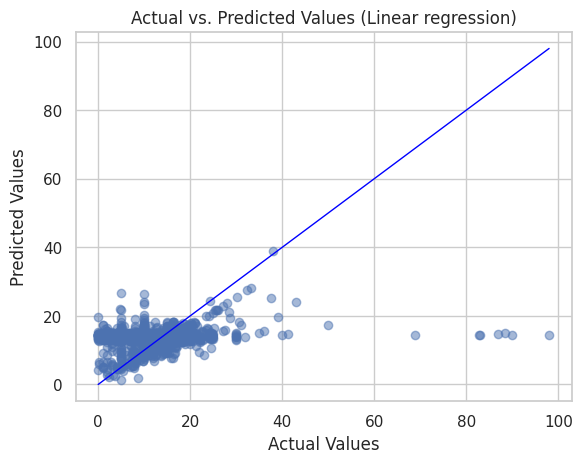

In [98]:
import matplotlib.pyplot as plt
plt.figure()

plt.scatter(y_test, test_pred, alpha = 0.5)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = 'blue', linewidth = 1)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values (Linear regression)')

plt.show()

In [99]:
#TASK TWO
obesity = pd.read_csv(OBESITY_URL)
obesity.shape

#2111 rows and 17 columns

(2111, 17)

In [100]:
obesity.head()

#categorical - gender, family_history_with_overweight, FAVC	, CAEC,	SMOKE, SCC, CALC,	MTRANS,	NObeyesdad
#numeric - Age	, Weight, FCVC,	NCP, CH2O, FAF,	TUE



,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [101]:
obesity.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [102]:
obesity.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [103]:
obesity.isna().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


In [104]:
obesity["NObeyesdad"].value_counts()

,count
NObeyesdad,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


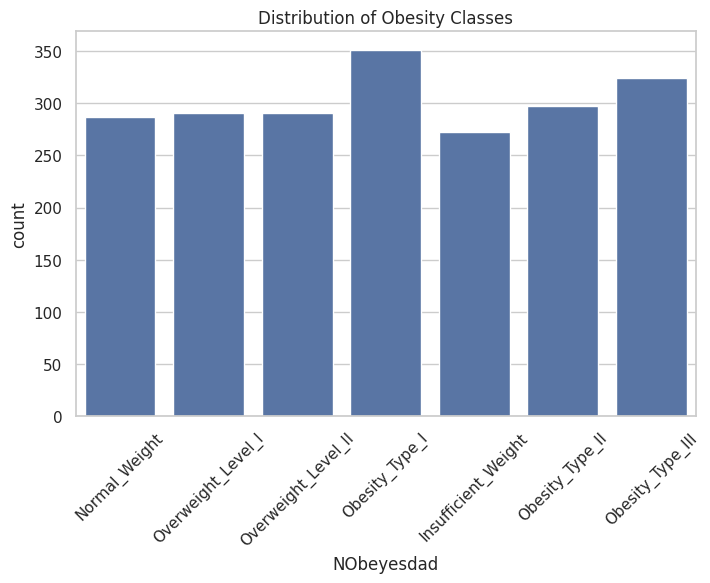

In [105]:
plt.figure(figsize=(8,5))
sns.countplot(data=obesity, x="NObeyesdad")

plt.xticks(rotation=45)
plt.title("Distribution of Obesity Classes")
plt.show()

#The target consists of seven obesity classes that are relatively balanced. A balanced target helps prevent the classifier from becoming biased towards only one class.



In [106]:
#2.2
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']

for cols in binary_cols:
  obesity[cols] = obesity[cols].map({
      'yes': 1, 'no': 0
  })

categorical_cols = ['CAEC', 'CALC', 'Gender', 'MTRANS']
obesity = pd.get_dummies(obesity, columns = categorical_cols,  drop_first = True)


In [107]:
obesity['BMI'] = obesity['Weight'] / (obesity['Height'] ** 2)

In [108]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
obesity['NObeyesdad'] = label_encoder.fit_transform(obesity['NObeyesdad'])
X = obesity.drop('NObeyesdad', axis = 1)
y = obesity['NObeyesdad']
numeric_cols1 = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

#Binary variables were encoded as 0 and 1, while categorical variables with multiple categories were one-hot encoded. I also created BMI = Weight / Height squared because BMI is strongly related to obesity. Although BMI provides useful information, it is closely related to the target and therefore makes the classification task easier. I used StandardScaler to standardize the numeric variables before training.

In [109]:
#2.3
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.4,random_state=42,stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify= y_temp)

#I used a stratified 0.6/0.2/0.2 split so that each dataset contained approximately the same proportion of the seven obesity classes. Stratification prevents rare classes from disappearing from the validation. Without stratification, the model evaluation could become unreliable because some classes might be underrepresented.


In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_cols1] = scaler.fit_transform(X_train[numeric_cols1])

X_val[numeric_cols1] = scaler.transform(X_val[numeric_cols1])

X_test[numeric_cols1] = scaler.transform(X_test[numeric_cols1])

In [111]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,f1_score,classification_report,ConfusionMatrixDisplay)

rf_model = RandomForestClassifier(n_estimators=100,random_state=42)

rf_model.fit(X_train, y_train)

#Predictions
rf_train_pred = rf_model.predict(X_train)
rf_val_pred = rf_model.predict(X_val)
rf_test_pred = rf_model.predict(X_test)

#Accuracy
rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_val_acc = accuracy_score(y_val, rf_val_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)

#Macro F1
rf_train_f1 = f1_score(y_train, rf_train_pred, average="macro")
rf_val_f1 = f1_score(y_val, rf_val_pred, average="macro")
rf_test_f1 = f1_score(y_test, rf_test_pred, average="macro")

print(f"Train Accuracy: {rf_train_acc:.3f}")
print(f"Validation Accuracy: {rf_val_acc:.3f}")
print(f"Test Accuracy: {rf_test_acc:.3f}")


print(f"Train Macro-F1: {rf_train_f1:.3f}")
print(f"Validation Macro-F1: {rf_val_f1:.3f}")
print(f"Test Macro-F1: {rf_test_f1:.3f}")

print("Classification Report")
print(classification_report(y_test, rf_test_pred))


Train Accuracy: 1.000
Validation Accuracy: 0.986
Test Accuracy: 0.960
Train Macro-F1: 1.000
Validation Macro-F1: 0.985
Test Macro-F1: 0.959
Classification Report
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        54
           1       0.82      0.97      0.89        58
           2       0.97      1.00      0.99        70
           3       1.00      0.98      0.99        60
           4       0.98      1.00      0.99        65
           5       0.96      0.88      0.92        58
           6       1.00      0.93      0.96        58

    accuracy                           0.96       423
   macro avg       0.96      0.96      0.96       423
weighted avg       0.96      0.96      0.96       423



<Figure size 800x800 with 0 Axes>

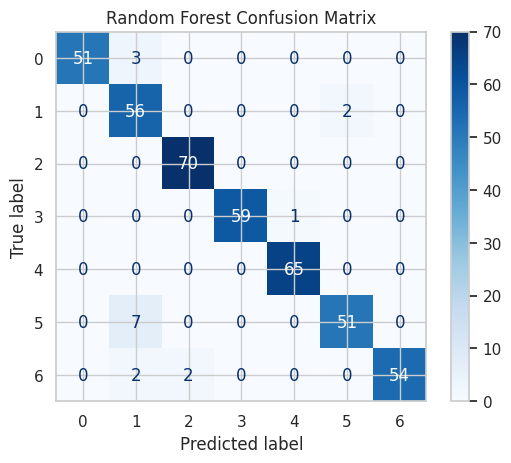

In [112]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 8))

ConfusionMatrixDisplay.from_predictions(y_test, rf_test_pred, cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.show()

#I chose the Random Forest Classifier because it handles complex relationships between variables. The small decrease from training to testing indicates slight overfitting, but the model still generalizes well because the validation and test scores remain high. The confusion matrix shows that neighbouring obesity categories are more likely to be confused because their characteristics are similar.

In [113]:
#TASK 3
from sklearn.preprocessing import StandardScaler
scaler2 = StandardScaler()
X_scaled = scaler2.fit_transform(X)

from sklearn.cluster import KMeans
inertia = []

for k in range(2,11):
  kmeans = KMeans(n_clusters=k, random_state=42, n_init = 10)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)


labels = kmeans.fit_predict(X_scaled)



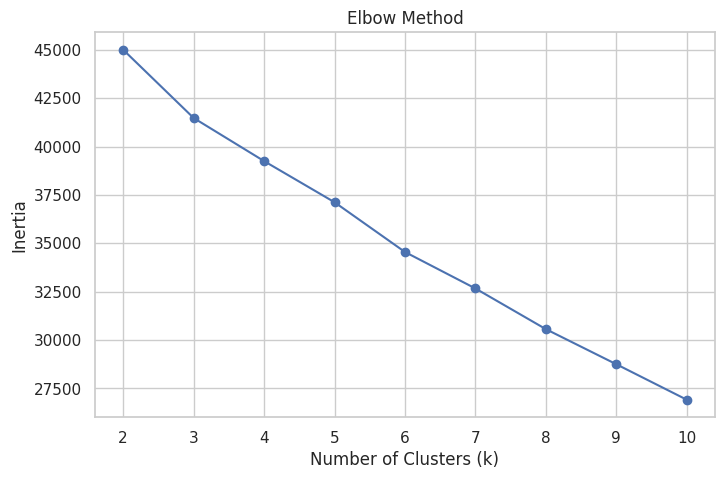

In [114]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [115]:
kmeans = KMeans(n_clusters = 6, random_state = 42, n_init = 10)
cluster_labels = kmeans.fit_predict(X_scaled)
print(cluster_labels[:20])

[2 0 2 2 0 0 0 0 2 2 5 5 0 2 0 5 0 2 5 0]


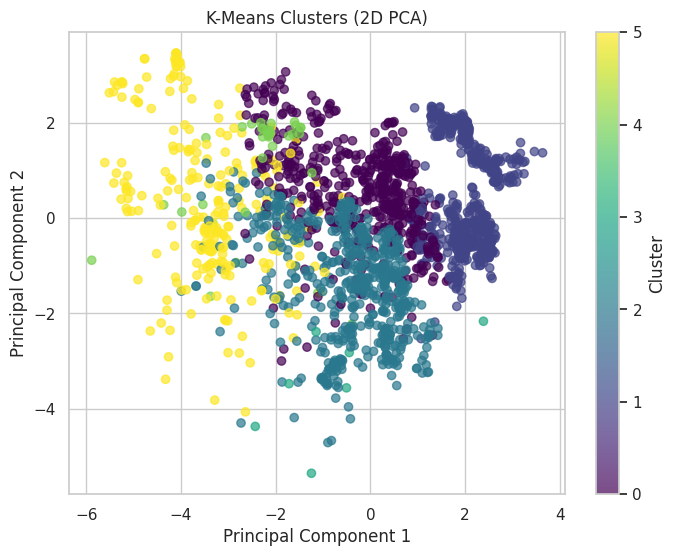

In [116]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

#reduction to 2d
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#cluster plotting
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="viridis", alpha=0.7)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters (2D PCA)")

plt.colorbar(label="Cluster")

plt.show()

In [117]:
import pandas as pd
comparison = pd.crosstab(cluster_labels, obesity["NObeyesdad"], rownames=["Cluster"], colnames=["Actual Obesity Level"])
print(comparison)

#I selected k = 6 using the Elbow Method. The inertia decreased rapidly up to 6 clusters and then began to level off, indicating that adding more clusters gave only small improvements.
#The clusters only partially matched the true obesity levels.
#This shows that K-Means identified some meaningful groups but did not perfectly separate the seven obesity categories.
#The clusters could help identify groups of people with similar health and lifestyle characteristics without requiring obesity labels. This information could be used for screening programmes.

Actual Obesity Level    0    1    2    3    4    5    6
Cluster                                                
0                      95  107   92    1    0  164  104
1                       0    0   77  222  323   19   30
2                      52   71  175   70    1   56  139
3                       0    4    0    1    0    2    0
4                       3   10    1    1    0   35    1
5                     122   95    6    2    0   14   16


REFLECTION
1. The classifier learned to predict the correct obesity category using labelled data, resulting in high accuracy. K-Means did not use labels but grouped people based on similarities in their features, helping identify natural patterns in the data.

2. Regression predicted a continuous value and was evaluated using RMSE and R². Classification predicted one of seven obesity categories and was evaluated using Accuracy, Macro-F1, and the confusion matrix.

3. The biggest train-versus-test gap occurred with the Random Forest Regressor, where the training R² was 0.67 but the test R² dropped to −0.19, indicating overfitting. To reduce overfitting, I would tune the model by limiting tree depth, increasing the minimum samples per leaf.